# Notebook 03: Pareto Analysis & Zeolite Ranking

**Inputs**:
- `zeolite_features_targets.csv` (from Notebook 01)
- `best_models.pkl`, `model_metadata.json` (from Notebook 02)

**Goals**:
1. Predict all three targets for every zeolite using the best model(s).
2. Construct Pareto fronts (maximize capacity & selectivity, minimize regeneratio energy).
3. Rank zeolites per-target and by composite score.
4. Export final ranked CSV.

## 1.0 Environment Setup & Data Loading

In [1]:
import warnings, pickle, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load feature/target data
df = pd.read_csv("zeolite_features_targets.csv", index_col="code")

with open("model_metadata.json") as f:
    meta = json.load(f)

TARGET_COLS  = meta["target_columns"]
FEATURE_COLS = meta["feature_columns"]

X_all = df[FEATURE_COLS].values
y_all = df[TARGET_COLS].values

with open("best_models.pkl", "rb") as f:
    best_models = pickle.load(f)

## 2.0 Generate Predictions for All Zeolites

We use both the best single-target models and the best multi-output model to produce predictions, then average them for a robust consensus estimate.

In [2]:
# Single-target predictions
pred_single = np.zeros_like(y_all)
for tgt_idx, tgt_name in enumerate(TARGET_COLS):
    model = best_models.get(tgt_name)
    if model is not None:
        try:
            pred_single[:, tgt_idx] = model.predict(X_all)
        except Exception:
            # Multi-output model - extract relevant column
            pred_single[:, tgt_idx] = model.predict(X_all)[:, tgt_idx] if model.predict(X_all).ndim > 1 else model.predict(X_all)

# Multi-output predictions
multi_model = best_models.get("_multi_output")
if multi_model is not None:
    pred_multi = multi_model.predict(X_all)
else:
    pred_multi = pred_single  # fallback

# Ensemble average (equal weight)
pred_ensemble = 0.5 * pred_single + 0.5 * pred_multi

df_pred = pd.DataFrame(pred_ensemble, index=df.index, columns=[
    "pred_CO2_capacity",
    "pred_CO2_N2_selectivity",
    "pred_desorption_energy"
])

# Merge with actual targets for reference
df_results = df[TARGET_COLS].join(df_pred)
print(df_results.head(5))

      CO2_capacity_mmol_g  CO2_N2_selectivity  desorption_energy_kJ_mol  \
code                                                                      
ABW              0.200000           12.000000                 24.000000   
ACO              0.658653           33.015675                 30.371623   
AEI              2.300000           90.000000                 35.000000   
AEL              0.500000           14.000000                 26.000000   
AEN              0.479189           18.200676                 27.083229   

      pred_CO2_capacity  pred_CO2_N2_selectivity  pred_desorption_energy  
code                                                                      
ABW            0.288375                12.062219               24.037935  
ACO            0.664836                32.986310               30.363407  
AEI            2.217942                89.941069               35.015319  
AEL            0.519917                14.035708               26.004857  
AEN            0.491175 

## 3.0 Pareto-Front Identification

A zeolite is Pareto-optimal if no other zeolite simultaneously has higher capacity, higher selectivity, and lower regeneration energy. The `paretoset` library is used. The Pareto set defines the efficiency frontier; any improvement in one objective requires sacrificing another.

In [3]:
# paretoset: !pip install paretoset
try:
    from paretoset import paretoset
    PARETOSET_AVAILABLE = True
except ImportError:
    PARETOSET_AVAILABLE = False
    print("paretoset not installed - using manual_pareto_mask function for non-dominated sort")

def manual_pareto_mask(costs):
    """
    Return boolean mask of Pareto-optimal rows.
    costs: (n, m) array where LOWER is better for ALL columns.
    """
    n = len(costs)
    is_pareto = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_pareto[i]:
            continue
        for j in range(n):
            if i == j or not is_pareto[j]:
                continue
            # j dominates i if j <= i on all objectives and j < i on at least one
            if np.all(costs[j] <= costs[i]) and np.any(costs[j] < costs[i]):
                is_pareto[i] = False
                break
    return is_pareto

In [4]:
# Build objective matrix: we want max capacity, max selectivity, min energy
# For Pareto: convert all to minimization (negate capacity & selectivity)
obj_matrix = df_pred.copy()
obj_matrix.columns = ["capacity", "selectivity", "energy"]

if PARETOSET_AVAILABLE:
    pareto_mask = paretoset(
        obj_matrix[["capacity", "selectivity", "energy"]],
        sense=["max", "max", "min"]
    )
else:
    # Manual: convert to all-minimize
    costs = np.column_stack([
        -obj_matrix["capacity"].values,
        -obj_matrix["selectivity"].values,
        obj_matrix["energy"].values,
    ])
    pareto_mask = manual_pareto_mask(costs)

df_pred["pareto_optimal"] = pareto_mask
n_pareto = pareto_mask.sum()
print(f"Pareto-optimal zeolites: {n_pareto} / {len(df_pred)}")
print(f"\nPareto set:")
print(df_pred[df_pred["pareto_optimal"]].sort_values("pred_CO2_capacity", ascending=False).to_string())

Pareto-optimal zeolites: 58 / 229

Pareto set:
      pred_CO2_capacity  pred_CO2_N2_selectivity  pred_desorption_energy  pareto_optimal
code                                                                                    
FAU            2.954742                84.929742               37.958904            True
EMT            2.871600                75.027050               36.960684            True
RHO            2.782767               118.949587               41.850132            True
SAO            2.493899                80.853229               33.721706            True
KFI            2.340487                87.632690               39.446640            True
AFX            2.304621                94.944827               35.986260            True
ITV            2.237051                65.057644               30.519365            True
CHA            2.228728                87.755556               35.931482            True
AEI            2.217942                89.941069               

### 3.1 2D Pareto Projections

Three pairwise views highlight the trade-off surfaces. Pareto-optimal zeolites are shown as red stars; dominated zeolites as blue circles.

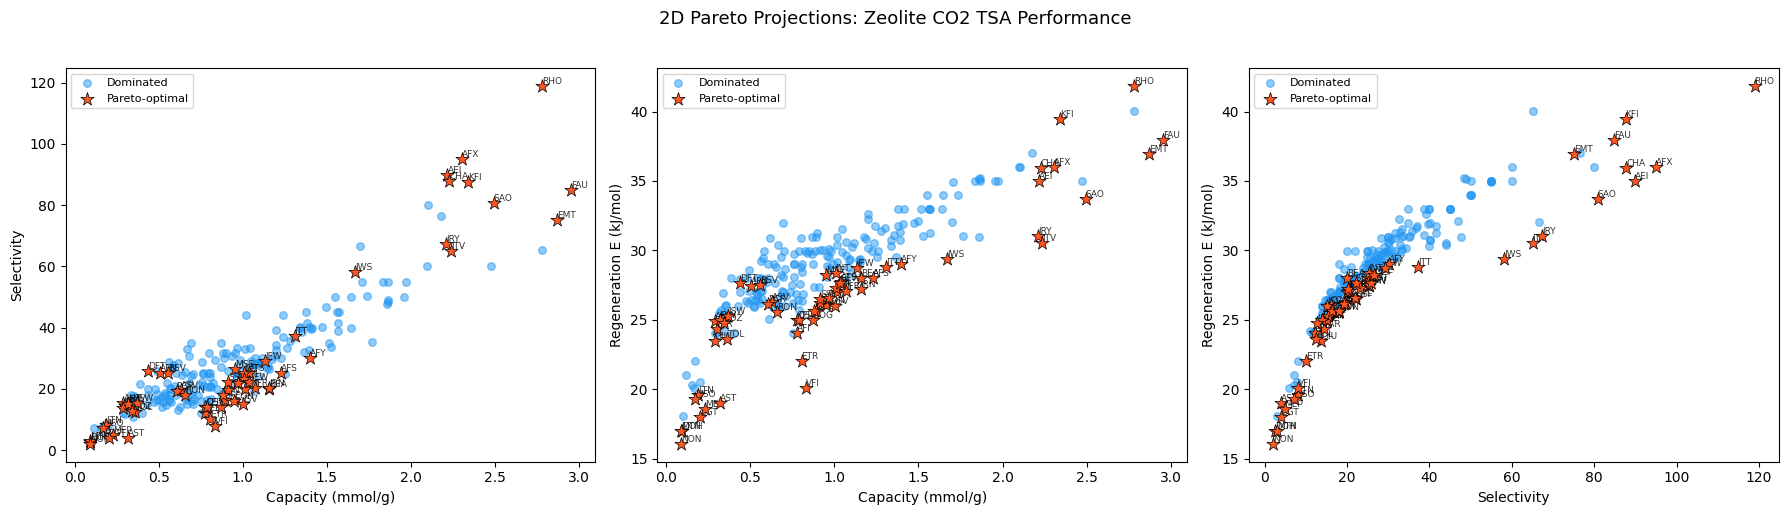

In [5]:
pairs = [
    ("pred_CO2_capacity", "pred_CO2_N2_selectivity", "Capacity (mmol/g)", "Selectivity"),
    ("pred_CO2_capacity", "pred_desorption_energy",  "Capacity (mmol/g)", "Regeneration E (kJ/mol)"),
    ("pred_CO2_N2_selectivity", "pred_desorption_energy", "Selectivity", "Regeneration E (kJ/mol)"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (xcol, ycol, xlab, ylab) in zip(axes, pairs):
    dominated = ~df_pred["pareto_optimal"]
    ax.scatter(df_pred.loc[dominated, xcol], df_pred.loc[dominated, ycol],
               s=30, alpha=0.5, c="#2196F3", label="Dominated")
    ax.scatter(df_pred.loc[pareto_mask, xcol], df_pred.loc[pareto_mask, ycol],
               s=100, marker="*", c="#FF5722", edgecolors="black", linewidths=0.5,
               label="Pareto-optimal", zorder=5)
    
    # Label Pareto points
    for code_str in df_pred.index[pareto_mask]:
        ax.annotate(code_str, (df_pred.loc[code_str, xcol], df_pred.loc[code_str, ycol]),
                    fontsize=6.5, ha="left", va="bottom", alpha=0.8)
    
    ax.set_xlabel(xlab); ax.set_ylabel(ylab)
    ax.legend(fontsize=8)

plt.suptitle("2D Pareto Projections: Zeolite CO2 TSA Performance", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 3.2 3D Pareto Visualization

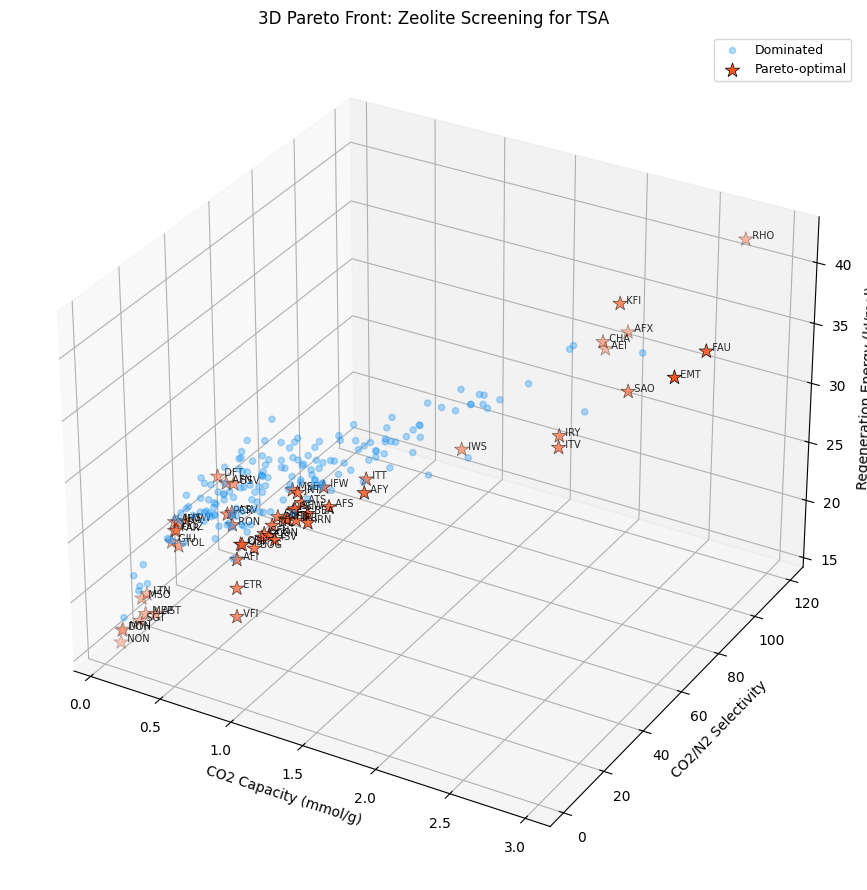

In [6]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

dominated = ~df_pred["pareto_optimal"]
ax.scatter(df_pred.loc[dominated, "pred_CO2_capacity"],
           df_pred.loc[dominated, "pred_CO2_N2_selectivity"],
           df_pred.loc[dominated, "pred_desorption_energy"],
           s=20, alpha=0.35, c="#2196F3", label="Dominated")

ax.scatter(df_pred.loc[pareto_mask, "pred_CO2_capacity"],
           df_pred.loc[pareto_mask, "pred_CO2_N2_selectivity"],
           df_pred.loc[pareto_mask, "pred_desorption_energy"],
           s=120, marker="*", c="#FF5722", edgecolors="black", linewidths=0.5,
           label="Pareto-optimal", zorder=5)

for code_str in df_pred.index[pareto_mask]:
    ax.text(df_pred.loc[code_str, "pred_CO2_capacity"],
            df_pred.loc[code_str, "pred_CO2_N2_selectivity"],
            df_pred.loc[code_str, "pred_desorption_energy"],
            f"  {code_str}", fontsize=7, alpha=0.85)

ax.set_xlabel("CO2 Capacity (mmol/g)")
ax.set_ylabel("CO2/N2 Selectivity")
ax.set_zlabel("Regeneration Energy (kJ/mol)")
ax.set_title("3D Pareto Front: Zeolite Screening for TSA", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 3.3 Composite Scoring & Per-Target Rankings

**Composite score** uses min-max normalized objectives with configurable weights.
Default: 40% capacity + 40% selectivity + 20% (1 − energy).

This weighting reflects TSA priorities: high working capacity and selectivity
drive process economics, while desorption energy (regeneration cost) is important
but often addressed through process optimization (vacuum level, temperature).

Adjust `WEIGHTS` below to match your specific priorities.

In [7]:
WEIGHTS = {
    "capacity":    0.40,
    "selectivity": 0.40,
    "energy":      0.20,  # weight for (1 - normalized energy)
}

def minmax(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-12)

df_rank = df_pred[["pred_CO2_capacity","pred_CO2_N2_selectivity",
                    "pred_desorption_energy","pareto_optimal"]].copy()

df_rank["norm_capacity"]    = minmax(df_rank["pred_CO2_capacity"])
df_rank["norm_selectivity"] = minmax(df_rank["pred_CO2_N2_selectivity"])
df_rank["norm_energy"]      = minmax(df_rank["pred_desorption_energy"])

df_rank["composite_score"] = (
    WEIGHTS["capacity"]    * df_rank["norm_capacity"] +
    WEIGHTS["selectivity"] * df_rank["norm_selectivity"] +
    WEIGHTS["energy"]      * (1 - df_rank["norm_energy"])
)

# Per-target ranks (1 = best)
df_rank["rank_capacity"]    = df_rank["pred_CO2_capacity"].rank(ascending=False).astype(int)
df_rank["rank_selectivity"] = df_rank["pred_CO2_N2_selectivity"].rank(ascending=False).astype(int)
df_rank["rank_energy"]      = df_rank["pred_desorption_energy"].rank(ascending=True).astype(int)
df_rank["rank_composite"]   = df_rank["composite_score"].rank(ascending=False).astype(int)

df_rank = df_rank.sort_values("rank_composite")
print("Top 20 zeolites by composite score:\n")
display_cols = ["pred_CO2_capacity","pred_CO2_N2_selectivity","pred_desorption_energy",
                "composite_score","rank_capacity","rank_selectivity","rank_energy",
                "rank_composite","pareto_optimal"]
print(df_rank[display_cols].head(20).to_string(float_format="{:.3f}".format))

Top 20 zeolites by composite score:

      pred_CO2_capacity  pred_CO2_N2_selectivity  pred_desorption_energy  composite_score  rank_capacity  rank_selectivity  rank_energy  rank_composite  pareto_optimal
code                                                                                                                                                                   
RHO               2.783                  118.950                  41.850            0.776              3                 1          229               1            True
FAU               2.955                   84.930                  37.959            0.714              1                 6          226               2            True
EMT               2.872                   75.027                  36.961            0.676              2                10          224               3            True
AFX               2.305                   94.945                  35.986            0.673              8                 2 

### 3.4 Heatmap: Top 10 Zeolites Across All Objectives

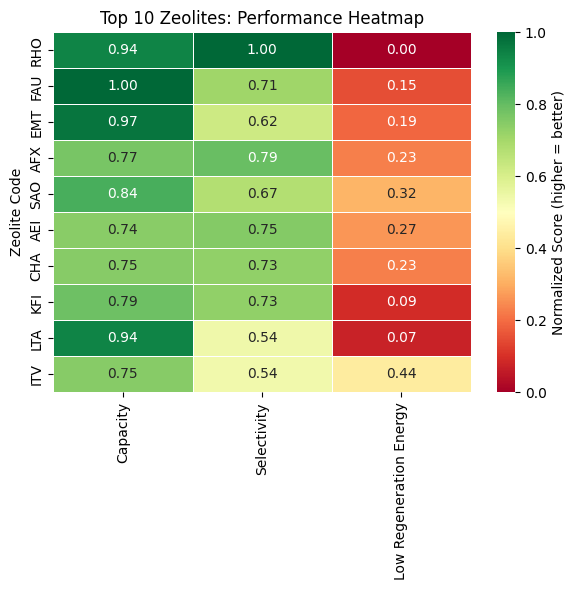

In [8]:
top10 = df_rank.head(10)
heatmap_data = top10[["norm_capacity", "norm_selectivity"]].copy()
heatmap_data["norm_low_energy"] = 1 - top10["norm_energy"]
heatmap_data.columns = ["Capacity", "Selectivity", "Low Regeneration Energy"]

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            cbar_kws={"label": "Normalized Score (higher = better)"})

ax.set_title("Top 10 Zeolites: Performance Heatmap", fontsize=12)
ax.set_ylabel("Zeolite Code")
plt.tight_layout()
plt.show()

### 3.5 Pareto Plot with Composite Score Coloring

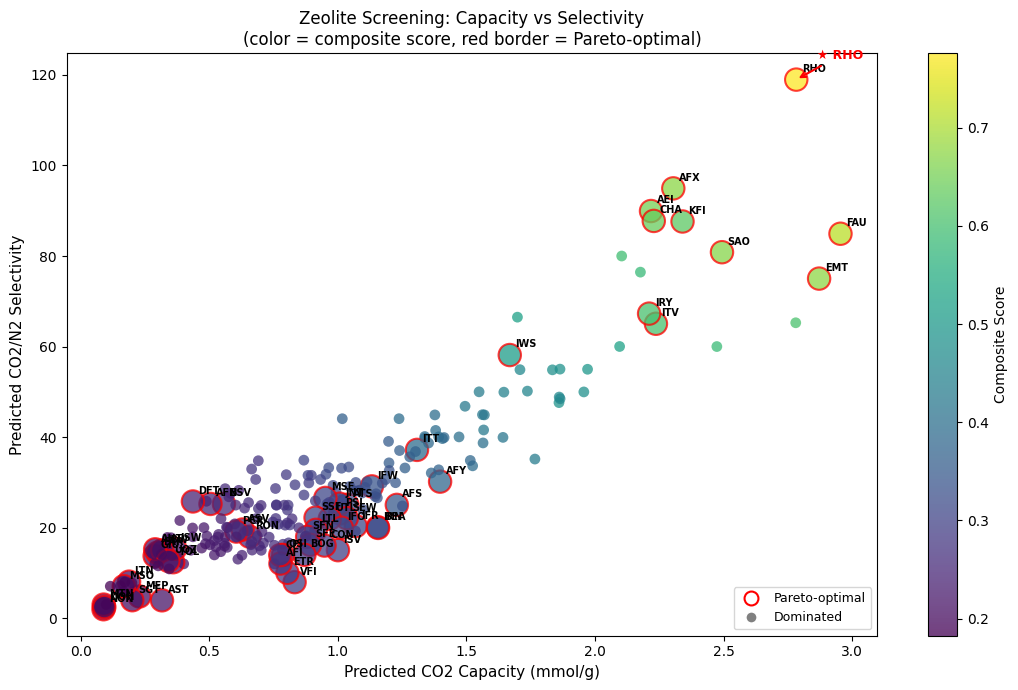

In [9]:
fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(
    df_rank["pred_CO2_capacity"],
    df_rank["pred_CO2_N2_selectivity"],
    c=df_rank["composite_score"],
    cmap="viridis",
    s=60 + 200 * df_rank["pareto_optimal"].astype(float),  # Pareto points are larger
    alpha=0.75,
    edgecolors=np.where(df_rank["pareto_optimal"], "red", "none"),
    linewidths=np.where(df_rank["pareto_optimal"], 1.5, 0),
)

cbar = plt.colorbar(scatter, ax=ax, label="Composite Score")

# Annotate Pareto-optimal zeolites
for code_str in df_rank.index[df_rank["pareto_optimal"]]:
    ax.annotate(
        code_str,
        (df_rank.loc[code_str, "pred_CO2_capacity"],
         df_rank.loc[code_str, "pred_CO2_N2_selectivity"]),
        fontsize=7, fontweight="bold", ha="left", va="bottom",
        xytext=(4, 4), textcoords="offset points",
    )

# Mark the top composite scorer
top_code = df_rank.index[0]
ax.annotate(
    f"★ {top_code}", fontsize=9, fontweight="bold", color="red",
    xy=(df_rank.loc[top_code, "pred_CO2_capacity"],
        df_rank.loc[top_code, "pred_CO2_N2_selectivity"]),
    xytext=(15, 15), textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="red", lw=1.5),
)

ax.set_xlabel("Predicted CO2 Capacity (mmol/g)", fontsize=11)
ax.set_ylabel("Predicted CO2/N2 Selectivity", fontsize=11)
ax.set_title("Zeolite Screening: Capacity vs Selectivity\n"
             "(color = composite score, red border = Pareto-optimal)", fontsize=12)
legend_elements = [
    Line2D([0],[0], marker="o", color="w", markeredgecolor="red", markeredgewidth=1.5,
           markersize=10, label="Pareto-optimal"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="grey",
           markersize=8, label="Dominated"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## 4.0 Cluster Analysis: Top Zeolite Candidates

Three performance clusters emerge from the composite ranking. **Cluster A** (RHO, FAU, EMT) occupies the high-capacity, high-selectivity upper-right region. **Cluster B** (AFX, AEI, CHA, KFI) forms a tight group of small-pore cage zeolites with moderate capacity and high selectivity. **Cluster C** (SAO, ITV) is distinguished by low regeneration energy (E_R < 34 kJ/mol) rather than spatial proximity in the capacity–selectivity plane.

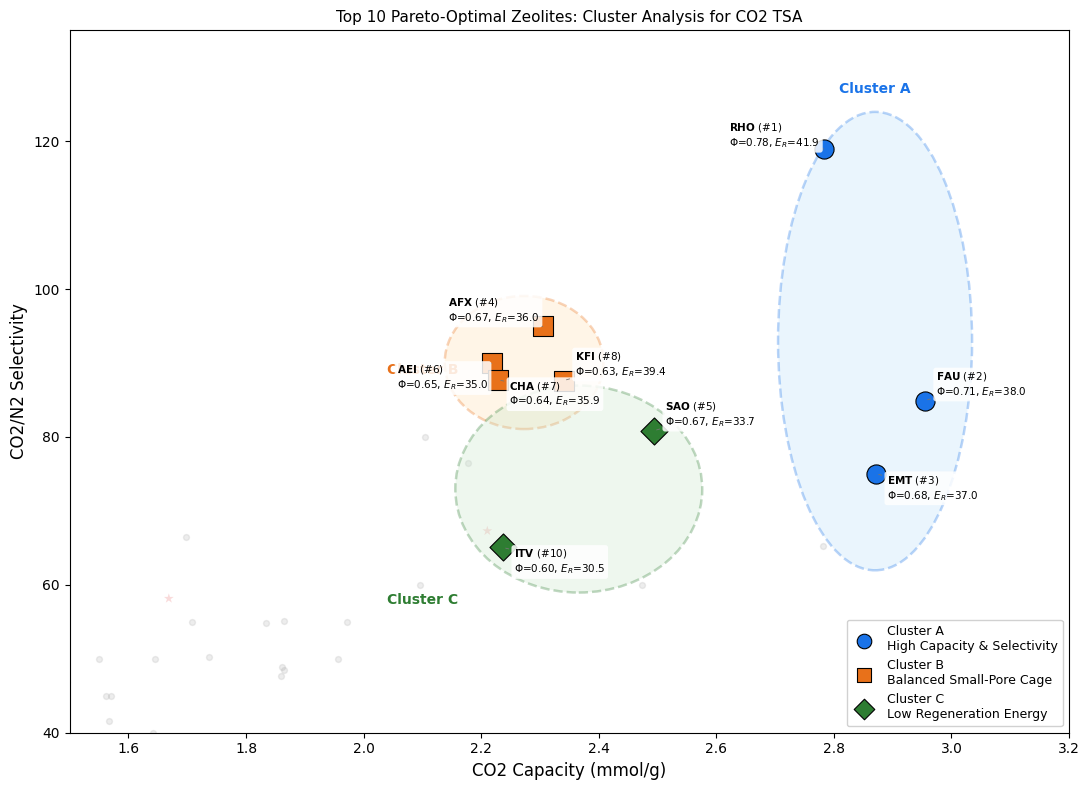

In [10]:
from matplotlib.patches import Ellipse

# Cluster Definitions
CLUSTERS = {
    "A": {
        "label": "Cluster A\nHigh Capacity & Selectivity",
        "codes": ["RHO", "FAU", "EMT"],
        "color": "#1A73E8",
        "marker": "o",
        # ellipse: (cx, cy, width, height)
        "ellipse": (2.870, 92.97, 0.33, 62),
    },
    "B": {
        "label": "Cluster B\nBalanced Small-Pore Cage",
        "codes": ["AFX", "AEI", "CHA", "KFI"],
        "color": "#E8711A",
        "marker": "s",
        "ellipse": (2.273, 90.07, 0.27, 18),
    },
    "C": {
        "label": "Cluster C\nLow Regeneration Energy",
        "codes": ["SAO", "ITV"],
        "color": "#2E7D32",
        "marker": "D",
        "ellipse": (2.366, 72.96, 0.42, 28),
    },
}

# annotation offsets (points) for each zeolite label
OFFSETS = {
    "RHO": (-68, 2),
    "FAU": (8,  4),
    "EMT": (8, -18),
    "AFX": (-68,  4),
    "AEI": (-68, -18),
    "CHA": (8,  -18),
    "KFI": (8,   4),
    "SAO": (8,   4),
    "ITV": (8,  -18),
}

cluster_codes = [c for cl in CLUSTERS.values() for c in cl["codes"]]

fig, ax = plt.subplots(figsize=(11, 8))

ax.scatter(
    df_rank.loc[~df_rank["pareto_optimal"], "pred_CO2_capacity"],
    df_rank.loc[~df_rank["pareto_optimal"], "pred_CO2_N2_selectivity"],
    s=18, alpha=0.18, c="#9E9E9E", zorder=1,
)

# Pareto-Optimal Non-Cluster Data Points
pareto_bg = df_rank[df_rank["pareto_optimal"] & ~df_rank.index.isin(cluster_codes)]
ax.scatter(
    pareto_bg["pred_CO2_capacity"],
    pareto_bg["pred_CO2_N2_selectivity"],
    s=55, marker="*", alpha=0.35, c="#EF9A9A", edgecolors="none", zorder=2,
)

# Cluster Ellipses
ellipse_facecolors = {"A": "#BBDEFB", "B": "#FFE0B2", "C": "#C8E6C9"}
for cid, cl in CLUSTERS.items():
    cx, cy, w, h = cl["ellipse"]
    e = Ellipse(
        (cx, cy), width=w, height=h,
        facecolor=ellipse_facecolors[cid], edgecolor=cl["color"],
        alpha=0.30, linewidth=1.8, linestyle="--", zorder=3,
    )
    ax.add_patch(e)

# Cluster Data Point Scatter
legend_handles = []
for cid, cl in CLUSTERS.items():
    x = df_rank.loc[cl["codes"], "pred_CO2_capacity"]
    y = df_rank.loc[cl["codes"], "pred_CO2_N2_selectivity"]
    ax.scatter(x, y, s=190, c=cl["color"], marker=cl["marker"],
               edgecolors="black", linewidths=0.8, zorder=6)
    legend_handles.append(
        ax.scatter([], [], s=110, c=cl["color"], marker=cl["marker"],
                   edgecolors="black", linewidths=0.8, label=cl["label"])
    )

# Annotations/Labels
for code in cluster_codes:
    row   = df_rank.loc[code]
    rank  = row["rank_composite"]
    score = row["composite_score"]
    er    = row["pred_desorption_energy"]
    cap   = row["pred_CO2_capacity"]
    sel   = row["pred_CO2_N2_selectivity"]
    ox, oy = OFFSETS.get(code, (8, 4))

    ax.annotate(
        f"$\\mathbf{{{code}}}$ (#{rank})\nΦ={score:.2f}, $E_R$={er:.1f}",
        xy=(cap, sel), xytext=(ox, oy),
        textcoords="offset points", fontsize=7.5,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85),
        arrowprops=dict(arrowstyle="-", color="#757575", lw=0.6),
        zorder=7,
    )

# Cluster Labels
ax.text(2.870, 127, "Cluster A", fontsize=10, fontweight="bold", color="#1A73E8", ha="center", va="center")
ax.text(2.100, 89,  "Cluster B", fontsize=10, fontweight="bold", color="#E8711A", ha="center", va="center")
ax.text(2.100, 58,  "Cluster C", fontsize=10, fontweight="bold", color="#2E7D32", ha="center", va="center")

ax.set_xlabel("CO2 Capacity (mmol/g)", fontsize=12)
ax.set_ylabel("CO2/N2 Selectivity", fontsize=12)
ax.set_title("Top 10 Pareto-Optimal Zeolites: Cluster Analysis for CO2 TSA", fontsize=11)
ax.legend(handles=legend_handles, loc="lower right", fontsize=9, framealpha=0.9)
ax.set_xlim(1.5, 3.2)
ax.set_ylim(40, 135)
plt.tight_layout()
plt.show()

## 5.0 Export Final Rankings

In [11]:
OUTPUT_CSV = "zeolite_rankings.csv"
export_cols = [
    "pred_CO2_capacity", "pred_CO2_N2_selectivity", "pred_desorption_energy",
    "norm_capacity", "norm_selectivity", "norm_energy", "composite_score",
    "rank_capacity", "rank_selectivity", "rank_energy", "rank_composite",
    "pareto_optimal",
]

df_rank[export_cols].to_csv(OUTPUT_CSV)
print(f"Exported {OUTPUT_CSV} - {len(df_rank)} zeolites ranked")
print(f"\nPareto-optimal frameworks ({n_pareto}):")
print(", ".join(df_rank.index[df_rank["pareto_optimal"]].tolist()))

Exported zeolite_rankings.csv - 229 zeolites ranked

Pareto-optimal frameworks (58):
RHO, FAU, EMT, AFX, SAO, AEI, CHA, KFI, ITV, IRY, IWS, ITT, AFY, AFS, IFW, IRN, ATS, BEA, IFR, PSI, JNT, SEW, MSE, UTL, IFO, SSF, LTL, ISV, VFI, SFN, CON, SFE, ETR, BOG, OSI, AFI, CFI, RON, ASV, BSV, PCR, AFN, DFT, AST, TOL, JSW, GIU, MEP, FAR, LTN, SGT, JBW, AHT, UOZ, MSO, NON, MTN, DOH
